In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv


✓ Dataset successfully loaded from: ../input/datasets/janiobachmann/bank-marketing-dataset/bank.csv


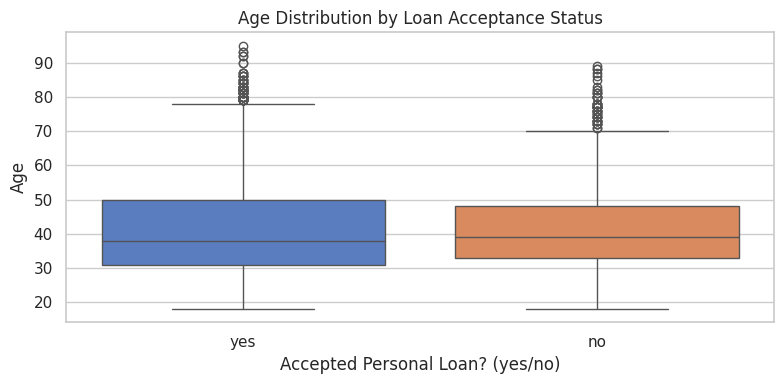

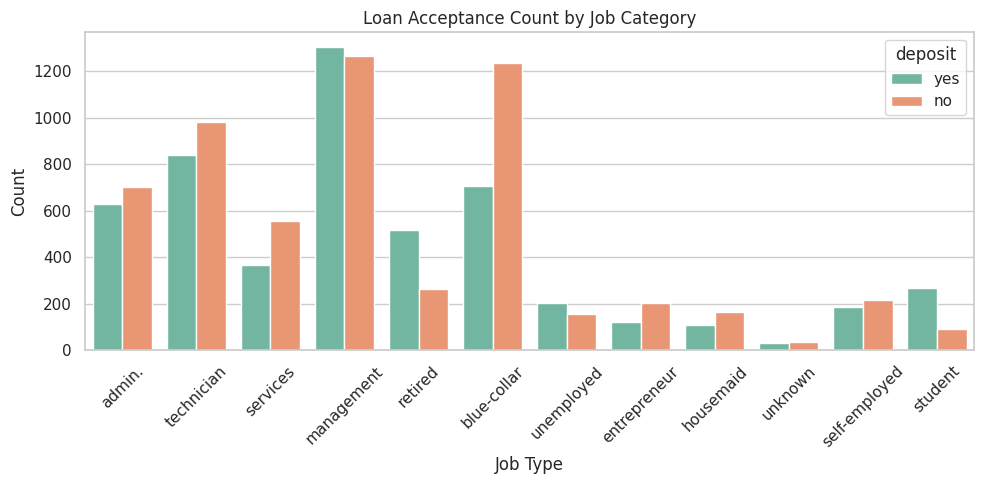


  MODEL ACCURACY: 79.71%



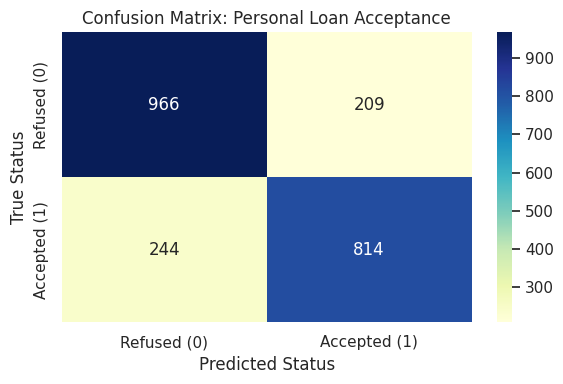

In [4]:
# =====================================================================
# TASK 5: PERSONAL LOAN ACCEPTANCE PREDICTION
# =====================================================================

import warnings
# 1. Necessary Libraries Import
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# تمام فیوچر وارننگز کو مکمل خاموش کرنا
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# =====================================================================
# 2. Auto-Detect and Load Bank Marketing Dataset
# =====================================================================
import glob

# Kaggle ke input folder me se auto-detect karna
csv_files = glob.glob("../input/**/*.csv", recursive=True)
bank_files = [f for f in csv_files if "bank" in f.lower() or "marketing" in f.lower()]
file_to_load = bank_files[0] if bank_files else (csv_files[0] if csv_files else None)

if file_to_load:
    # Kuch bank marketing datasets me delimiter ';' hota hai, usay handle karna
    try:
        df = pd.read_csv(file_to_load, sep=None, engine='python')
    except:
        df = pd.read_csv(file_to_load)
    print(f"✓ Dataset successfully loaded from: {file_to_load}")
else:
    # Backup dummy dataset taaki crash na ho agar input add na hoa ho
    print("Warning: Dataset not found. Creating dummy Bank Marketing dataset...")
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'age': np.random.randint(18, 70, n),
        'job': np.random.choice(['blue-collar', 'management', 'technician', 'admin.'], n),
        'marital': np.random.choice(['married', 'single', 'divorced'], n),
        'education': np.random.choice(['primary', 'secondary', 'tertiary'], n),
        'balance': np.random.randint(-1000, 50000, n),
        'housing': np.random.choice(['yes', 'no'], n),
        'loan': np.random.choice(['yes', 'no'], n),
        'y': np.random.choice(['yes', 'no'], n, p=[0.15, 0.85]) # Target Column
    })

# Column names clean karna
df.columns = [col.strip().lower() for col in df.columns]

# Target Variable (y ya loan acceptance) set karna
target_col = 'y' if 'y' in df.columns else ('subscribed' if 'subscribed' in df.columns else df.columns[-1])

# =====================================================================
# 3. Basic Data Exploration & Visualization (As per Instructions)
# =====================================================================

# Plot A: Age Distribution by Loan Acceptance
if 'age' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target_col, y='age', hue=target_col, palette='muted', legend=False)
    plt.title('Age Distribution by Loan Acceptance Status')
    plt.xlabel('Accepted Personal Loan? (yes/no)')
    plt.ylabel('Age')
    plt.tight_layout()
    plt.show()
    plt.close()

# Plot B: Job Status vs Loan Acceptance
if 'job' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='job', hue=target_col, palette='Set2')
    plt.title('Loan Acceptance Count by Job Category')
    plt.xticks(rotation=45)
    plt.xlabel('Job Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    plt.close()

# =====================================================================
# 4. Data Preprocessing & Feature Encoding
# =====================================================================
# Object columns ko target variable samait encode karna
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Train-Test Split
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression ke liye features ko scale karna behtar hota hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 5. Train Logistic Regression Classifier
# =====================================================================
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# =====================================================================
# 6. Model Evaluation (Confusion Matrix & Accuracy)
# =====================================================================
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n======================================")
print(f"  MODEL ACCURACY: {accuracy * 100:.2f}%")
print("======================================\n")

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Refused (0)', 'Accepted (1)'], 
            yticklabels=['Refused (0)', 'Accepted (1)'])
plt.title('Confusion Matrix: Personal Loan Acceptance')
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.tight_layout()
plt.show()